<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Assignment%202/Econ_5200_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(10086)

normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [3]:
def calculate_mad(data):
  data = np.asarray(data, dtype=float)

  x = np.sort(data)
  n = len(x)
  middle = n//2
  if n%2 == 1:
    median = x[middle]
  else:
    median = (x[middle-1]+x[middle])/2

  absolute_dev=np.abs(data-median)

  y = np.sort(absolute_dev)
  m = len(y)
  middle2 = m//2
  if m%2 == 1:
    MAD = y[middle2]
  else:
    MAD = (y[middle2-1]+y[middle2])/2

  return float(MAD)

In [4]:
print ("SD", np.std(latency_logs))
print ("Mad", calculate_mad(latency_logs))

SD 517.703928403098
Mad 8.0


Ans: SD is calculated based on (xi-x bar)^2/n-1. This means that the square deviation mean-reliance property would raise the issues regarding to the extreme value. To be specific, the extreme value might be far away from the mean value, also the square property would cause the deviation greater. Therefore, it would lead to a significant proportion after it is squared, no matter how much proportion of the outliers is it actually make up. Comparing to MAD, MAD rely on median and absolute deviation. MAD's calculation property ensures it is less likely to be impacted by the extreme values in the total data. Therefore, MAD would not be impacted heavily as SD under 20 outliers condition.

# Phase 2:

In [5]:
def bayesian_audit(prior, sensitivity, specificity):
  P_Cheater = prior
  P_Isnot_Cheater = 1-P_Cheater
  P_Flagged_Cheater = sensitivity
  P_Flagged_Isnot_Cheater = 1-specificity

  P_Flagged=P_Flagged_Cheater * P_Cheater + P_Flagged_Isnot_Cheater * P_Isnot_Cheater

  return (P_Flagged_Cheater * P_Cheater)/P_Flagged

In [6]:
sensitivity = 0.98
specificity = 0.98

Scene A:

In [7]:
print("Scene A Bootcamp-BR(50%):", bayesian_audit(0.50, sensitivity, specificity))

Scene A Bootcamp-BR(50%): 0.98


Scene B:


In [8]:
print("Scene B Econ Class-BR(5%):", bayesian_audit(0.05, sensitivity, specificity))

Scene B Econ Class-BR(5%): 0.7205882352941175


Scene C:


In [9]:
print("Scene C Honors Seminar-BR(0.1%)", bayesian_audit(0.001, sensitivity, specificity))

Scene C Honors Seminar-BR(0.1%) 0.04675572519083965


# Phase 3:

In [13]:
total =  50250+49750
observed = np.array([50250, 49750])
expected = np.array([total/2, total/2])

print(total)
print(observed)
print(expected)

100000
[50250 49750]
[50000. 50000.]


In [20]:
def chi_square_test(observed, expected):
  chi_square_calc=0
  for i in range(len(observed)):
    chi_square_calc += ((observed[i]-expected[i])**2/expected[i])
  return chi_square_calc

chi_square_result=chi_square_test(observed, expected)

print (chi_square_result)


2.5


In [33]:
if chi_square_result > 3.84:
 print ("Invalid(Due to Engineering Bias)")
else:
 print ("Valid")

Valid


# Phase 4: AI Expansion

Share below $1: 0.9915
Share below $10: 0.9915
       SURVIVORSHIP BIAS — CRYPTO TOKEN LAUNCHES
  Total tokens simulated : 10,000
  Survivors (top 1%)     : 100
-------------------------------------------------------
  ALL TOKENS  — Mean Peak MCap : $      1,149.75
  ALL TOKENS  — Median Peak MCap: $          0.25
  SURVIVORS   — Mean Peak MCap : $    114,950.66
  SURVIVORS   — Median Peak MCap: $     72,607.69
-------------------------------------------------------
  Survivorship Bias Multiplier  : 100.0x


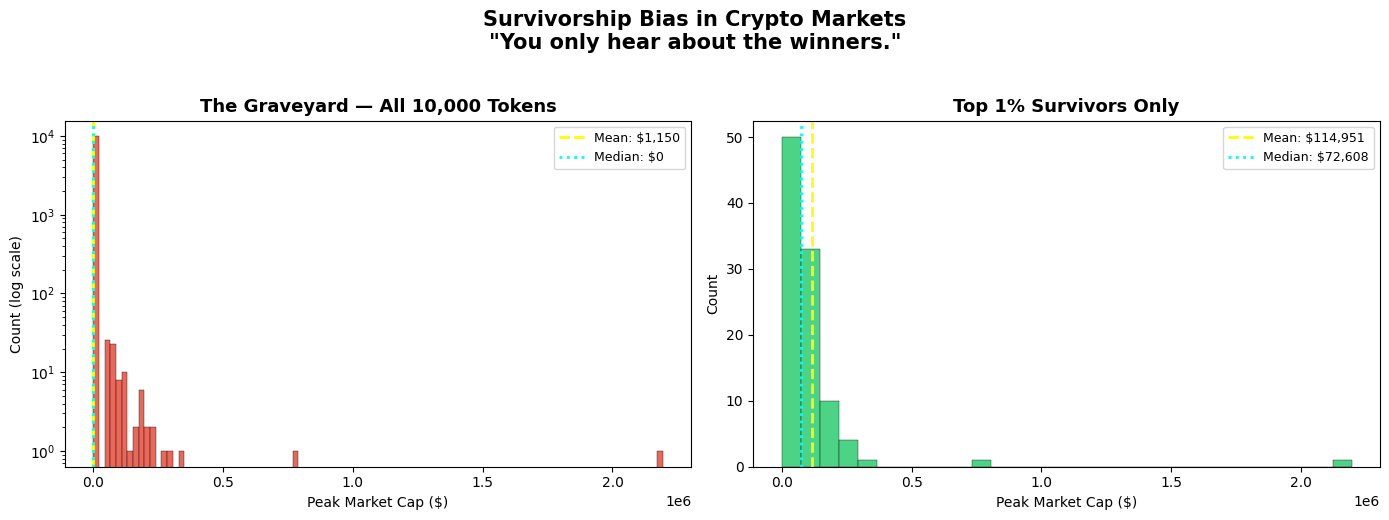

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(10086)

# --- Simulate 10,000 Token Launches ---
n = 10000

# --- Mixture Model DGP ---
# 99% of tokens fail (near-zero market cap), 1% "moon" via Pareto tail
fail_mask = np.random.rand(n) < 0.99  # True = failed token

# Failed tokens: tiny noise near zero (pennies)
failed_mcap = np.random.uniform(0, 0.50, size=n)

# Winners (1%): Pareto power-law, scaled to reach large values
winner_mcap = (np.random.pareto(a=1.5, size=n) + 1) * 50_000

# Combine: failed tokens stay near 0, winners get Pareto draw
peak_mcap = np.where(fail_mask, failed_mcap, winner_mcap)

# --- Sanity Checks ---
print("Share below $1:", (peak_mcap < 1).mean())
print("Share below $10:", (peak_mcap < 10).mean())

# --- Build DataFrames ---
df_all = pd.DataFrame({"Peak_Market_Cap": peak_mcap})
df_all["Label"] = "All Tokens (The Graveyard)"

# Top 1% survivors
threshold = np.percentile(peak_mcap, 99)
df_survivors = df_all[df_all["Peak_Market_Cap"] >= threshold].copy()
df_survivors["Label"] = "Top 1% Survivors"

# --- Stats ---
mean_all = df_all["Peak_Market_Cap"].mean()
median_all = df_all["Peak_Market_Cap"].median()
mean_survivors = df_survivors["Peak_Market_Cap"].mean()
median_survivors = df_survivors["Peak_Market_Cap"].median()

print("=" * 55)
print("       SURVIVORSHIP BIAS — CRYPTO TOKEN LAUNCHES")
print("=" * 55)
print(f"  Total tokens simulated : {n:,}")
print(f"  Survivors (top 1%)     : {len(df_survivors):,}")
print("-" * 55)
print(f"  ALL TOKENS  — Mean Peak MCap : ${mean_all:>14,.2f}")
print(f"  ALL TOKENS  — Median Peak MCap: ${median_all:>14,.2f}")
print(f"  SURVIVORS   — Mean Peak MCap : ${mean_survivors:>14,.2f}")
print(f"  SURVIVORS   — Median Peak MCap: ${median_survivors:>14,.2f}")
print("-" * 55)
print(f"  Survivorship Bias Multiplier  : {mean_survivors/mean_all:,.1f}x")
print("=" * 55)

# --- Dual Histogram Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: The Graveyard (all tokens, log scale)
axes[0].hist(df_all["Peak_Market_Cap"], bins=100, color="#e74c3c", alpha=0.85, edgecolor="black", linewidth=0.3)
axes[0].axvline(mean_all, color="yellow", linestyle="--", linewidth=2, label=f"Mean: ${mean_all:,.0f}")
axes[0].axvline(median_all, color="cyan", linestyle=":", linewidth=2, label=f"Median: ${median_all:,.0f}")
axes[0].set_yscale("log")
axes[0].set_title("The Graveyard — All 10,000 Tokens", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Peak Market Cap ($)")
axes[0].set_ylabel("Count (log scale)")
axes[0].legend(fontsize=9)

# Right: Survivors only
axes[1].hist(df_survivors["Peak_Market_Cap"], bins=30, color="#2ecc71", alpha=0.85, edgecolor="black", linewidth=0.3)
axes[1].axvline(mean_survivors, color="yellow", linestyle="--", linewidth=2, label=f"Mean: ${mean_survivors:,.0f}")
axes[1].axvline(median_survivors, color="cyan", linestyle=":", linewidth=2, label=f"Median: ${median_survivors:,.0f}")
axes[1].set_title("Top 1% Survivors Only", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Peak Market Cap ($)")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=9)

plt.suptitle("Survivorship Bias in Crypto Markets\n\"You only hear about the winners.\"",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("survivorship_bias_crypto.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
print("Share below $1:", (peak_mcap < 1).mean())
print("Share below $10:", (peak_mcap < 10).mean())

Share below $1: 0.9915
Share below $10: 0.9915
